# Producción de H2V Distribuida - Modelo Punto por Punto

## 🎯 Objetivo
Calcular el **potencial de producción de hidrógeno verde (H2V)** en cada ubicación geográfica del Valle de Aconcagua.

## 🔧 CORRECCIÓN IMPLEMENTADA (Nov 2025)
**Problema identificado**: Demanda constante de 100 GWh/mes para todos los puntos → sobredimensionamiento 330×

**Solución aplicada**:
- ✅ Demanda variable temporal desde `demand_h2_monthly_MWh.csv` (2023-2100)
- ✅ Distribución espacial: demanda_total / 330 puntos
- ✅ Conservación verificada: Σ(puntos) = demanda_total_valle
- ✅ Cada punto recibe ~10.38 TWh (en lugar de 24 TWh constantes)

## 🏗️ Arquitectura del Modelo
**Modelo DISTRIBUIDO**: 330 sistemas independientes (uno por punto de grilla)

```
Punto 1:  PV(CF=0.207) → Electrolyzer → H2_Storage → Demanda_distribuida
Punto 2:  PV(CF=0.217) → Electrolyzer → H2_Storage → Demanda_distribuida
...
Punto 330: PV(CF=0.253) → Electrolyzer → H2_Storage → Demanda_distribuida
```

**Sin transmisión entre puntos** → Cada ubicación es evaluada independientemente

## 📊 Outputs
- Matriz espacial: `[lat, lon, cap_pv_mw, cap_electrolyzer_mw, h2_ton_year, lcoh_usd_kg]`
- **Producción por década**: Columnas `h2_prod_2020s_ton`, `h2_prod_2030s_ton`, etc.
- Mapas de potencial H2 por ubicación
- Identificación de mejores zonas (top 10%, 20%, 50%)
- Comparación entre escenarios SSP

## ⚙️ Configuración Técnica
- **Optimizador**: Calliope v0.6.x
- **Solver**: GLPK
- **Período**: 2015-2100 (1032 meses) o subconjunto de prueba
- **Escenarios**: SSP245, SSP370, SSP585
- **Demanda distribuida**: Temporal (2023-2100) y espacial (÷330 puntos)

---

## 1️⃣ Imports y Configuración Inicial

In [2]:
# Imports
import calliope
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import datetime
import yaml
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print(f"✓ Calliope version: {calliope.__version__}")
print(f"✓ Imports completados")

✓ Calliope version: 0.6.10
✓ Imports completados


## 2️⃣ Configuración de Rutas y Parámetros

In [3]:
# ========== CONFIGURACIÓN PRINCIPAL ==========

# Rutas del proyecto
BASE_DIR = Path('/home/aninotna/magister/tesis/justh2_pipeline')
CALLIOPE_DIR = BASE_DIR / 'scripts' / 'calliope_v6'
DATA_DIR = BASE_DIR / 'data'
PV_CF_DIR = CALLIOPE_DIR / 'data' / 'pv_cf_batch'  # 🔧 CORREGIDO: Ruta correcta a archivos CSV

# Escenario a procesar
SCENARIO = 'ssp245'  # 'ssp245', 'ssp370', 'ssp585'

# 🔧 OUTPUT_DIR incluye escenario para evitar sobrescritura
OUTPUT_DIR = DATA_DIR / 'h2v_production_spatial' / 'distributed_point_by_point' / SCENARIO
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

# Modo de ejecución
TEST_MODE = False  # True = quick test (2023-2043), False = full period (2015-2100)
N_POINTS_SAMPLE = None  # Número de puntos para prueba (None = todos los 330)

# 🔧 CORRECCIÓN: Cargar demanda mensual total del valle
DEMAND_MONTHLY_FILE = CALLIOPE_DIR / 'data' / 'demand_h2_monthly_MWh.csv'
df_demand_total = pd.read_csv(DEMAND_MONTHLY_FILE, parse_dates=['timesteps'])
demand_total_series = df_demand_total.set_index('timesteps')['VALPO'].abs()

# Parámetros del modelo
N_TOTAL_POINTS = 330  # Total de puntos espaciales (desde locations_batch.yml)
# La demanda se distribuirá uniformemente entre los N puntos

# Archivos de configuración Calliope
TECHS_YML = CALLIOPE_DIR / 'techs.yml'

print("=" * 80)
print("⚙️ CONFIGURACIÓN DEL MODELO DISTRIBUIDO")
print("=" * 80)
print(f"\n📁 Rutas:")
print(f"   Calliope dir: {CALLIOPE_DIR}")
print(f"   PV CF data: {PV_CF_DIR}")
print(f"   Output: {OUTPUT_DIR}")
print(f"   techs.yml: {TECHS_YML.exists()}")

print(f"\n🎯 Parámetros:")
print(f"   Escenario: {SCENARIO.upper()}")
print(f"   Test mode: {TEST_MODE} ({'2023-2043' if TEST_MODE else '2015-2100'})")
print(f"   Puntos a procesar: {N_POINTS_SAMPLE if N_POINTS_SAMPLE else 'TODOS (330)'}")

print(f"\n🔧 DEMANDA DISTRIBUIDA:")
print(f"   Archivo: {DEMAND_MONTHLY_FILE.name}")
print(f"   Total puntos: {N_TOTAL_POINTS}")
print(f"   Demanda total valle: {demand_total_series.sum() / 1e6:.2f} TWh")
print(f"   Demanda por punto: {demand_total_series.sum() / N_TOTAL_POINTS / 1e6:.2f} TWh")
print(f"   Rango mensual por punto: {demand_total_series.iloc[0] / N_TOTAL_POINTS:,.0f} - {demand_total_series.iloc[-1] / N_TOTAL_POINTS:,.0f} MWh")

# Estimación de tiempo
points_to_run = N_POINTS_SAMPLE if N_POINTS_SAMPLE else 330
time_per_point = 3 if TEST_MODE else 15  # segundos
total_time_min = (points_to_run * time_per_point) / 60
print(f"\n⏱️ Tiempo estimado: {total_time_min:.1f} minutos")

print(f"   ({points_to_run} puntos × ~{time_per_point}s/punto)")
print("=" * 80)

⚙️ CONFIGURACIÓN DEL MODELO DISTRIBUIDO

📁 Rutas:
   Calliope dir: /home/aninotna/magister/tesis/justh2_pipeline/scripts/calliope_v6
   PV CF data: /home/aninotna/magister/tesis/justh2_pipeline/scripts/calliope_v6/data/pv_cf_batch
   Output: /home/aninotna/magister/tesis/justh2_pipeline/data/h2v_production_spatial/distributed_point_by_point/ssp245
   techs.yml: True

🎯 Parámetros:
   Escenario: SSP245
   Test mode: False (2015-2100)
   Puntos a procesar: TODOS (330)

🔧 DEMANDA DISTRIBUIDA:
   Archivo: demand_h2_monthly_MWh.csv
   Total puntos: 330
   Demanda total valle: 3426.66 TWh
   Demanda por punto: 10.38 TWh
   Rango mensual por punto: 471 - 11,516 MWh

⏱️ Tiempo estimado: 82.5 minutos
   (330 puntos × ~15s/punto)


In [4]:
# ✅ VERIFICACIÓN RÁPIDA DE DEMANDA DISTRIBUIDA
print("\n" + "🔍 VERIFICACIÓN DE DISTRIBUCIÓN DE DEMANDA")
print("=" * 80)

# Calcular demanda por punto
demand_per_point = demand_total_series / N_TOTAL_POINTS

# Mostrar primeros meses
print("\nPrimeros 12 meses de demanda:")
print(f"{'Mes':<15} {'Total (MWh)':<15} {'Por Punto (MWh)':<20} {'N Puntos':<10}")
print("-" * 60)
for i in range(12):
    month = demand_total_series.index[i].strftime('%Y-%m')
    total = demand_total_series.iloc[i]
    per_point = demand_per_point.iloc[i]
    print(f"{month:<15} {total:>13,.0f} {per_point:>18,.2f} {N_TOTAL_POINTS:>8}")

# Verificación de conservación
total_sum = demand_total_series.sum()
distributed_sum = demand_per_point.sum() * N_TOTAL_POINTS
difference = abs(total_sum - distributed_sum)

print(f"\n✓ Verificación de conservación:")
print(f"  Demanda total original: {total_sum / 1e6:,.2f} TWh")
print(f"  Suma de {N_TOTAL_POINTS} puntos: {distributed_sum / 1e6:,.2f} TWh")
print(f"  Diferencia: {difference:,.2f} MWh")
print(f"  {'✅ CORRECTO' if difference < 1 else '⚠️ REVISAR'}")

print("=" * 80)


🔍 VERIFICACIÓN DE DISTRIBUCIÓN DE DEMANDA

Primeros 12 meses de demanda:
Mes             Total (MWh)     Por Punto (MWh)      N Puntos  
------------------------------------------------------------
2023-01               155,339             470.72      330
2023-02               155,339             470.72      330
2023-03               155,339             470.72      330
2023-04               155,339             470.72      330
2023-05               155,339             470.72      330
2023-06               155,339             470.72      330
2023-07               155,339             470.72      330
2023-08               155,339             470.72      330
2023-09               155,339             470.72      330
2023-10               155,339             470.72      330
2023-11               155,339             470.72      330
2023-12               155,339             470.72      330

✓ Verificación de conservación:
  Demanda total original: 3,426.66 TWh
  Suma de 330 puntos: 3,426.66 TW

## 3️⃣ Cargar Capacity Factor desde CSV por Escenario

In [5]:
# Cargar archivo CF del escenario (formato: time, PV_SITE_1, ..., PV_SITE_330)
print("Cargando datos PV CF del escenario...")

cf_file = PV_CF_DIR / f'pv_cf_{SCENARIO}.csv'

if not cf_file.exists():
    raise FileNotFoundError(f"No se encontró: {cf_file}")

# Cargar CSV con CF (formato amplio: time + 330 columnas de sitios)
df_cf_wide = pd.read_csv(cf_file)
df_cf_wide['time'] = pd.to_datetime(df_cf_wide['time'])

print(f"\n✓ Dataset cargado: {cf_file.name}")
print(f"   Filas (timesteps): {len(df_cf_wide):,}")
print(f"   Columnas (time + sites): {len(df_cf_wide.columns)}")

# Identificar columnas de sitios (PV_SITE_1, PV_SITE_2, etc.)
site_columns = [col for col in df_cf_wide.columns if col.startswith('PV_SITE_')]
n_sites = len(site_columns)

print(f"\n✓ Sitios detectados: {n_sites}")
print(f"   Timesteps: {len(df_cf_wide)} ({df_cf_wide['time'].min().year} - {df_cf_wide['time'].max().year})")

# 🔧 VERIFICAR Y REMOVER DUPLICADOS EN ÍNDICE DE TIEMPO
duplicates = df_cf_wide['time'].duplicated()
if duplicates.any():
    n_dups = duplicates.sum()
    print(f"\n⚠️ Se encontraron {n_dups} timesteps duplicados en el CSV")
    print(f"   Removiendo duplicados (conservando primera ocurrencia)...")
    df_cf_wide = df_cf_wide[~duplicates].reset_index(drop=True)
    print(f"   ✓ Dataset limpio: {len(df_cf_wide)} timesteps únicos")

# Crear diccionario para mapeo rápido: point_id -> pd.Series(CF temporal)
print("\nCreando índice por sitio para acceso rápido...")

cf_by_site = {}

for site_col in site_columns:
    # Extraer ID del sitio (PV_SITE_123 → 123)
    site_id = int(site_col.replace('PV_SITE_', ''))
    
    # Crear serie temporal con índice de tiempo (ahora sin duplicados)
    cf_series = pd.Series(
        df_cf_wide[site_col].values,
        index=df_cf_wide['time']
    )
    
    # Verificación adicional: asegurar índice único
    if not cf_series.index.is_unique:
        print(f"   ⚠️ Sitio {site_id}: Índice aún tiene duplicados, aplicando drop_duplicates...")
        cf_series = cf_series[~cf_series.index.duplicated(keep='first')]
    
    cf_by_site[site_id] = cf_series

print(f"✓ Índice creado: {len(cf_by_site)} sitios con series CF")
print(f"   IDs de sitios: {min(cf_by_site.keys())} a {max(cf_by_site.keys())}")

# Verificar que coincida con N_TOTAL_POINTS
if len(cf_by_site) != N_TOTAL_POINTS:
    print(f"\n⚠️ ADVERTENCIA: Se encontraron {len(cf_by_site)} sitios en CSV")
    print(f"   pero N_TOTAL_POINTS={N_TOTAL_POINTS}")
    print(f"   Ajustando N_TOTAL_POINTS a {len(cf_by_site)}")
    N_TOTAL_POINTS = len(cf_by_site)

Cargando datos PV CF del escenario...

✓ Dataset cargado: pv_cf_ssp245.csv
   Filas (timesteps): 1,032
   Columnas (time + sites): 331

✓ Sitios detectados: 330
   Timesteps: 1032 (2015 - 2100)

Creando índice por sitio para acceso rápido...
✓ Índice creado: 330 sitios con series CF
   IDs de sitios: 1 a 330


## 4️⃣ Funciones para Preparación de Datos por Punto

## ✅ Verificación de Corrección de Demanda Distribuida

**ANTES** (versión con error):
- Demanda constante: 100 GWh/mes para todos los puntos
- Todos los puntos tenían la misma demanda total
- Suma total = 330 × 24 TWh = 7,920 TWh (INCORRECTO)

**AHORA** (versión corregida):
- Demanda variable temporal desde `demand_h2_monthly_MWh.csv`
- Distribución espacial: demanda_total / 330 puntos
- Suma total = 3,426 TWh (CORRECTO)
- Cada punto recibe ~10.38 TWh en el periodo completo

In [6]:
def prepare_point_data(lat, lon, cf_series, point_id, output_dir, 
                       total_demand_series, n_total_points):
    """
    Prepara archivos CSV y YAML para un punto con DEMANDA DISTRIBUIDA.
    
    🔧 CAMBIO CLAVE: Distribuye la demanda total temporal entre N puntos espaciales.
    
    Parameters:
    -----------
    lat, lon : float
        Coordenadas del punto
    cf_series : pd.Series
        Serie temporal de CF (índice DatetimeIndex)
    point_id : int
        ID único del punto
    output_dir : Path
        Directorio base para guardar archivos
    total_demand_series : pd.Series
        Serie temporal de demanda TOTAL mensual en MWh (demanda del valle completo)
    n_total_points : int
        Número total de puntos espaciales (para distribución)
    
    Returns:
    --------
    dict : Diccionario con paths y metadata del punto
    """
    
    # Crear directorio para el punto
    point_dir = output_dir / f'point_{point_id}'
    point_dir.mkdir(exist_ok=True, parents=True)
    
    # 1. Archivo PV CF
    pv_cf_file = point_dir / 'pv_cf.csv'
    df_cf = pd.DataFrame({
        'time': cf_series.index,
        'PV_SITE': cf_series.values
    })
    df_cf.to_csv(pv_cf_file, index=False)
    
    # 2. Archivo Demanda H2 DISTRIBUIDA
    demand_file = point_dir / 'demand_h2_batch.csv'
    
    # 🔧 DISTRIBUIR demanda uniformemente entre puntos
    demand_per_point = total_demand_series / n_total_points
    
    # 🔧 ALINEAMIENTO TEMPORAL ROBUSTO: usar merge_asof para mapear por fecha
    df_cf_time = pd.DataFrame({
        'time': cf_series.index
    }).sort_values('time')
    
    df_demand_time = pd.DataFrame({
        'time': demand_per_point.index,
        'demand': demand_per_point.values
    }).sort_values('time')
    
    # Merge por proximidad temporal (encuentra la demanda más cercana para cada timestep de CF)
    df_merged = pd.merge_asof(
        df_cf_time,
        df_demand_time,
        on='time',
        direction='nearest',
        tolerance=pd.Timedelta(days=45)  # Tolerancia de ~1.5 meses
    )
    
    # Verificar si hubo NaNs (fechas fuera de rango)
    n_missing = df_merged['demand'].isna().sum()
    if n_missing > 0:
        # Rellenar con interpolación
        df_merged['demand'] = df_merged['demand'].interpolate(method='linear', limit_direction='both')
        
        # Si aún hay NaNs, usar último valor válido
        if df_merged['demand'].isna().any():
            df_merged['demand'] = df_merged['demand'].fillna(method='ffill').fillna(method='bfill')
    
    demand_aligned = pd.Series(
        df_merged['demand'].values,
        index=cf_series.index
    )
    
    # Crear DataFrame (valores NEGATIVOS para Calliope)
    df_demand = pd.DataFrame({
        'time': cf_series.index,
        'POINT': -demand_aligned.values  # Convención Calliope
    })
    df_demand.to_csv(demand_file, index=False)
    
    # 3. Archivo de locación (coordenadas + techs)
    locations_content = f"""locations:
  POINT:
    coordinates:
      lat: {lat:.6f}
      lon: {lon:.6f}
    techs:
      pv:
      electrolyzer:
      h2_store:
      demand_h2:
      water_supply:
      seawater_supply:
      desalination:
"""
    locations_file = point_dir / 'locations.yml'
    with open(locations_file, 'w') as f:
        f.write(locations_content)
    
    return {
        'point_id': point_id,
        'lat': lat,
        'lon': lon,
        'cf_mean': float(cf_series.mean()),
        'cf_std': float(cf_series.std()),
        'n_timesteps': len(cf_series),
        'demand_mean_mwh': float(demand_aligned.mean()),
        'demand_total_mwh': float(demand_aligned.sum()),
        'point_dir': point_dir,
        'pv_cf_file': pv_cf_file,
        'demand_file': demand_file,
        'locations_file': locations_file
    }

print("✓ Función prepare_point_data() definida (CON merge_asof temporal robusto)")

✓ Función prepare_point_data() definida (CON merge_asof temporal robusto)


## 5️⃣ Función para Ejecutar Modelo Calliope por Punto

In [7]:
def run_point_model(point_data, techs_yml_path, test_mode=True):
    """
    Ejecuta optimización Calliope para un punto específico.
    
    Parameters:
    -----------
    point_data : dict
        Diccionario con paths y metadata del punto
    techs_yml_path : Path
        Ruta al archivo techs.yml global
    test_mode : bool
        Si True, ejecuta subset 2023-2043
    
    Returns:
    --------
    dict : Resultados de la optimización (incluye series temporales por década)
    """
    
    point_id = point_data['point_id']
    
    try:
        # Crear configuración del modelo
        model_config = {
            'import': [str(techs_yml_path), str(point_data['locations_file'])],
            'model': {
                'name': f'H2V_Point_{point_id}',
                'timeseries_data_path': str(point_data['point_dir'])
            },
            'run': {
                'mode': 'plan',
                'solver': 'glpk',
                'ensure_feasibility': True
            }
        }
        
        # Guardar configuración temporal
        config_file = point_data['point_dir'] / 'model_config.yml'
        with open(config_file, 'w') as f:
            yaml.dump(model_config, f, default_flow_style=False)
        
        # Override para subset temporal
        override_dict = {}
        if test_mode:
            override_dict['model.subset_time'] = ['2023-01', '2043-12']
        
        # Cargar y ejecutar modelo
        model = calliope.Model(
            str(config_file),
            override_dict=override_dict if override_dict else None
        )
        
        model.run()
        results = model.results
        
        # Extraer resultados clave
        cap_pv = float(results.energy_cap.sel(loc_techs='POINT::pv').values)
        cap_electrolyzer = float(results.energy_cap.sel(loc_techs='POINT::electrolyzer').values)
        
        # Producción H2 - EXTRAER SERIE TEMPORAL COMPLETA
        h2_prod_ts = results.carrier_prod.sel(
            loc_tech_carriers_prod='POINT::electrolyzer::hydrogen'
        ).to_pandas()
        
        # Convertir a kg (MWh → kWh → kg, 33.3 kWh/kg)
        h2_prod_kg_ts = h2_prod_ts * 1000 / 33.3
        
        # Totales agregados
        h2_prod_mwh = float(h2_prod_ts.sum())
        h2_prod_kg = float(h2_prod_kg_ts.sum())
        h2_prod_ton = h2_prod_kg / 1000
        
        # DESAGREGACIÓN POR DÉCADA
        # Extraer año de cada timestep
        years = pd.DatetimeIndex(h2_prod_kg_ts.index).year
        
        # Agrupar por década
        decades = (years // 10) * 10  # 2023 → 2020, 2035 → 2030, etc.
        h2_by_decade = h2_prod_kg_ts.groupby(decades).sum() / 1000  # ton
        
        # Crear diccionario con producción por década
        decade_dict = {}
        for decade, prod_ton in h2_by_decade.items():
            decade_dict[f'h2_prod_{decade}s_ton'] = float(prod_ton)
        
        # Costos y LCOH
        total_cost = float(results.cost.sum().values)
        lcoh = total_cost / h2_prod_kg if h2_prod_kg > 0 else np.inf
        
        # Storage
        cap_storage = 0.0
        if 'POINT::h2_store' in results.storage_cap.loc_techs_store:
            cap_storage = float(results.storage_cap.sel(loc_techs_store='POINT::h2_store').values)
        
        # Construir resultado con desagregación temporal
        result = {
            'point_id': point_id,
            'lat': point_data['lat'],
            'lon': point_data['lon'],
            'cf_mean': point_data['cf_mean'],
            'cap_pv_mw': cap_pv,
            'cap_electrolyzer_mw': cap_electrolyzer,
            'cap_storage_mwh': cap_storage,
            'h2_prod_mwh': h2_prod_mwh,
            'h2_prod_kg': h2_prod_kg,
            'h2_prod_ton': h2_prod_ton,  # Total agregado
            'total_cost_usd': total_cost,
            'lcoh_usd_kg': lcoh,
            'status': 'success'
        }
        
        # Agregar columnas por década
        result.update(decade_dict)
        
        return result
        
    except Exception as e:
        import traceback
        error_msg = f"{str(e)}\n{traceback.format_exc()}"
        
        return {
            'point_id': point_id,
            'lat': point_data['lat'],
            'lon': point_data['lon'],
            'cf_mean': point_data['cf_mean'],
            'cap_pv_mw': np.nan,
            'cap_electrolyzer_mw': np.nan,
            'cap_storage_mwh': np.nan,
            'h2_prod_mwh': np.nan,
            'h2_prod_kg': np.nan,
            'h2_prod_ton': np.nan,
            'total_cost_usd': np.nan,
            'lcoh_usd_kg': np.nan,
            'status': 'failed',
            'error': error_msg[:500]
        }

print("✓ Función run_point_model() definida (con desagregación por década)")

✓ Función run_point_model() definida (con desagregación por década)


## 6️⃣ Loop Principal - Procesar Todos los Puntos

In [ ]:
# ========== LOOP MULTI-ESCENARIO AUTOMÁTICO ==========
# Itera sobre SSP245, SSP370 y SSP585 automáticamente

import time
import sys

# 🔧 PROTECCIÓN CONTRA EJECUCIÓN DUPLICADA
if 'EXECUTION_LOCK' in globals() and EXECUTION_LOCK:
    print("\n" + "🛑" * 40)
    print("⚠️ ADVERTENCIA: ESTA CELDA YA SE ESTÁ EJECUTANDO")
    print("🛑" * 40)
    print("\nPara evitar duplicados y colapso de memoria:")
    print("   1. Interrumpe el kernel (Ctrl+C)")
    print("   2. Reinicia el kernel (Restart Kernel)")
    print("   3. Vuelve a ejecutar las celdas de configuración (1-13)")
    print("   4. Ejecuta esta celda nuevamente")
    sys.exit("Ejecución bloqueada para evitar duplicados")

EXECUTION_LOCK = True

# Escenarios a procesar
scenarios_to_run = ['ssp245', 'ssp370', 'ssp585']

# Guardar resultados de todos los escenarios
all_scenarios_results = {}

try:
    for scenario in scenarios_to_run:
        print("\n\n" + "=" * 80)
        print(f"🌍 PROCESANDO ESCENARIO: {scenario.upper()}")
        print("=" * 80)
        
        # 1. Actualizar configuración del escenario
        SCENARIO = scenario
        OUTPUT_DIR = DATA_DIR / 'h2v_production_spatial' / 'distributed_point_by_point' / SCENARIO
        OUTPUT_DIR.mkdir(exist_ok=True, parents=True)
        
        print(f"\n📁 Output: {OUTPUT_DIR}")
        
        # 2. Cargar datos CF del escenario
        print(f"\nCargando datos PV CF para {scenario}...")
        cf_file = PV_CF_DIR / f'pv_cf_{scenario}.csv'
        
        if not cf_file.exists():
            print(f"⚠️ Archivo no encontrado: {cf_file}")
            print(f"   Saltando escenario {scenario}")
            continue
        
        # Cargar CSV con CF
        df_cf_wide = pd.read_csv(cf_file)
        df_cf_wide['time'] = pd.to_datetime(df_cf_wide['time'])
        
        print(f"✓ Dataset cargado: {cf_file.name}")
        print(f"   Timesteps: {len(df_cf_wide)} ({df_cf_wide['time'].min().year} - {df_cf_wide['time'].max().year})")
        
        # Verificar y remover duplicados
        duplicates = df_cf_wide['time'].duplicated()
        if duplicates.any():
            df_cf_wide = df_cf_wide[~duplicates].reset_index(drop=True)
            print(f"   ✓ Duplicados removidos: {len(df_cf_wide)} timesteps únicos")
        
        # Crear diccionario CF por sitio
        site_columns = [col for col in df_cf_wide.columns if col.startswith('PV_SITE_')]
        cf_by_site = {}
        
        for site_col in site_columns:
            site_id = int(site_col.replace('PV_SITE_', ''))
            cf_series = pd.Series(df_cf_wide[site_col].values, index=df_cf_wide['time'])
            
            if not cf_series.index.is_unique:
                cf_series = cf_series[~cf_series.index.duplicated(keep='first')]
            
            cf_by_site[site_id] = cf_series
        
        print(f"✓ Índice creado: {len(cf_by_site)} sitios con series CF")
        
        # 3. Cargar coordenadas
        print("\nCargando coordenadas de locations_batch.yml...")
        LOCATIONS_YML = CALLIOPE_DIR / 'locations_batch.yml'
        
        with open(LOCATIONS_YML, 'r') as f:
            locations_data = yaml.safe_load(f)
        
        coords_by_site = {}
        for loc_name, loc_config in locations_data['locations'].items():
            if loc_name.startswith('PV_SITE_'):
                site_id = int(loc_name.replace('PV_SITE_', ''))
                coords = loc_config.get('coordinates', {})
                coords_by_site[site_id] = (coords.get('lat'), coords.get('lon'))
        
        print(f"✓ Coordenadas cargadas: {len(coords_by_site)} sitios")
        
        # 4. Preparar lista de puntos
        print("\nPreparando lista de puntos...")
        points_list = []
        
        for site_id in sorted(cf_by_site.keys()):
            if site_id not in coords_by_site:
                continue
            
            lat, lon = coords_by_site[site_id]
            cf_series = cf_by_site[site_id]
            
            points_list.append({
                'point_id': site_id,
                'lat': lat,
                'lon': lon,
                'cf_series': cf_series
            })
        
        # Limitar a muestra si N_POINTS_SAMPLE está definido
        if N_POINTS_SAMPLE:
            step = max(1, len(points_list) // N_POINTS_SAMPLE)
            points_list = points_list[::step][:N_POINTS_SAMPLE]
        
        print(f"✓ {len(points_list)} puntos listos para procesar")
        print(f"   Primeros 3: Sitios {points_list[0]['point_id']}, {points_list[1]['point_id']}, {points_list[2]['point_id']}")
        
        # 5. EJECUTAR OPTIMIZACIÓN
        print("\n" + "=" * 80)
        print(f"🚀 INICIANDO OPTIMIZACIÓN: {scenario.upper()}")
        print("=" * 80)
        
        results_list = []
        start_time = datetime.datetime.now()
        
        for idx, point_info in enumerate(points_list, 1):
            print(f"\nProcesando punto {idx}/{len(points_list)}: Sitio {point_info['point_id']}")
            # Preparar datos del punto CON DEMANDA DISTRIBUIDA
            point_data = prepare_point_data(
                lat=point_info['lat'],
                lon=point_info['lon'],
                cf_series=point_info['cf_series'],
                point_id=point_info['point_id'],
                output_dir=OUTPUT_DIR,
                total_demand_series=demand_total_series,
                n_total_points=N_TOTAL_POINTS
            )
            
            # Ejecutar modelo Calliope
            result = run_point_model(
                point_data=point_data,
                techs_yml_path=TECHS_YML,
                test_mode=TEST_MODE
            )
            
            results_list.append(result)
            
            # Mostrar progreso
            elapsed = (datetime.datetime.now() - start_time).total_seconds()
            rate = idx / elapsed if elapsed > 0 else 0
            remaining = (len(points_list) - idx) / rate if rate > 0 else 0
            
            status_icon = "✓" if result['status'] == 'success' else "✗"
            h2_val = f"{result.get('h2_prod_ton', 0):.1f}" if result['status'] == 'success' else "N/A"
            
            # 🔧 FLUSH para evitar buffer duplicado
            print(f"  [{idx:3d}/{len(points_list)}] {status_icon} Sitio {point_info['point_id']:3d} "
                  f"({point_info['lat']:.3f}, {point_info['lon']:.3f}) | "
                  f"H2: {h2_val} ton | "
                  f"Restante: {remaining/60:.1f} min", flush=True)
            
            # 🔧 LIBERAR MEMORIA cada 10 puntos
            if idx % 10 == 0:
                import gc
                gc.collect()
        
        elapsed_total = (datetime.datetime.now() - start_time).total_seconds()
        
        # 6. Consolidar y guardar resultados
        print("\n" + "=" * 80)
        print(f"✅ {scenario.upper()} COMPLETADO")
        print("=" * 80)
        print(f"⏱️  Tiempo total: {elapsed_total:.1f}s ({elapsed_total/60:.1f} min)")
        print(f"📊 Puntos procesados: {len(results_list)}")
        print(f"   Exitosos: {sum(1 for r in results_list if r['status'] == 'success')}")
        print(f"   Fallidos: {sum(1 for r in results_list if r['status'] == 'failed')}")
        print(f"⚡ Tasa promedio: {len(results_list)/elapsed_total:.2f} puntos/segundo")
        
        # Crear DataFrame y exportar
        df_results = pd.DataFrame(results_list)
        df_success = df_results[df_results['status'] == 'success'].copy()
        
        mode_str = 'test' if TEST_MODE else 'full'
        csv_path = OUTPUT_DIR / f'h2_distributed_{scenario}_{mode_str}.csv'
        df_results.to_csv(csv_path, index=False)
        print(f"\n💾 CSV guardado: {csv_path.name}")
        
        # Guardar para análisis comparativo
        all_scenarios_results[scenario] = {
            'df_results': df_results,
            'df_success': df_success,
            'elapsed_time': elapsed_total
        }
        
        # Pequeña pausa entre escenarios y liberación de memoria
        if scenario != scenarios_to_run[-1]:
            print(f"\n⏸️  Pausa de 5 segundos y liberación de memoria...")
            import gc
            gc.collect()
            time.sleep(5)
    
    # RESUMEN FINAL
    print("\n\n" + "=" * 80)
    print("🎉 TODOS LOS ESCENARIOS COMPLETADOS")
    print("=" * 80)
    print("\n📊 Resumen de ejecución:")
    for scenario in scenarios_to_run:
        if scenario in all_scenarios_results:
            data = all_scenarios_results[scenario]
            success_count = len(data['df_success'])
            total_count = len(data['df_results'])
            print(f"   {scenario.upper()}: {success_count}/{total_count} puntos exitosos ({data['elapsed_time']/60:.1f} min)")
    
    print("\n✅ Variables actualizadas en memoria:")
    print(f"   all_scenarios_results: {len(all_scenarios_results)} escenarios")
    print(f"   Cada escenario contiene: df_results, df_success, elapsed_time")
    print("=" * 80)

finally:
    # 🔧 LIBERAR LOCK al terminar (exitoso o con error)
    EXECUTION_LOCK = False
    print("\n🔓 Lock de ejecución liberado")



🌍 PROCESANDO ESCENARIO: SSP245

📁 Output: /home/aninotna/magister/tesis/justh2_pipeline/data/h2v_production_spatial/distributed_point_by_point/ssp245

Cargando datos PV CF para ssp245...
✓ Dataset cargado: pv_cf_ssp245.csv
   Timesteps: 1032 (2015 - 2100)
✓ Índice creado: 330 sitios con series CF

Cargando coordenadas de locations_batch.yml...
✓ Coordenadas cargadas: 330 sitios

Preparando lista de puntos...
✓ 330 puntos listos para procesar
   Primeros 3: Sitios 1, 2, 3

🚀 INICIANDO OPTIMIZACIÓN: SSP245
  [  1/330] ✓ Sitio   1 (-33.225, -71.725) | H2: 20991.3 ton | Restante: 16.3 min
  [  1/330] ✓ Sitio   1 (-33.225, -71.725) | H2: 20991.3 ton | Restante: 16.3 min
  [  2/330] ✓ Sitio   2 (-33.225, -71.625) | H2: 21956.6 ton | Restante: 16.4 min
  [  2/330] ✓ Sitio   2 (-33.225, -71.625) | H2: 21956.6 ton | Restante: 16.4 min
  [  3/330] ✓ Sitio   3 (-33.225, -71.525) | H2: 22447.3 ton | Restante: 16.5 min
  [  3/330] ✓ Sitio   3 (-33.225, -71.525) | H2: 22447.3 ton | Restante: 16.5 

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7fa85a09db10>>
Traceback (most recent call last):
  File "/home/aninotna/.conda/envs/calliope_env/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


## 6️⃣-B Loop Principal PARALELO (Multiprocessing)

⚡ **VERSIÓN ACELERADA**: Ejecuta 4-6 puntos simultáneamente usando CPU multi-core

**Ventajas**:
- ~5-6× más rápido (82 min → 15-20 min para 330 puntos)
- Usa todos los cores disponibles de tu CPU
- Consume más RAM (~20-25 GB en lugar de ~4 GB)

**Cuándo usar esta versión**:
- Tienes >20 GB RAM disponibles
- Quieres resultados más rápidos
- Ejecutas en modo `TEST_MODE=False` (periodo completo)

In [8]:
# ========== LOOP MULTI-ESCENARIO PARALELO ==========
# Versión con multiprocessing para acelerar 5-6×

import time
import sys
from multiprocessing import Pool, Manager, cpu_count
from functools import partial
import traceback

# 🔧 PROTECCIÓN CONTRA EJECUCIÓN DUPLICADA
if 'EXECUTION_LOCK' in globals() and EXECUTION_LOCK:
    print("\n" + "🛑" * 40)
    print("⚠️ ADVERTENCIA: ESTA CELDA YA SE ESTÁ EJECUTANDO")
    print("🛑" * 40)
    print("\nPara evitar duplicados y colapso de memoria:")
    print("   1. Interrumpe el kernel (Ctrl+C)")
    print("   2. Reinicia el kernel (Restart Kernel)")
    print("   3. Vuelve a ejecutar las celdas de configuración (1-13)")
    print("   4. Ejecuta esta celda nuevamente")
    sys.exit("Ejecución bloqueada para evitar duplicados")

EXECUTION_LOCK = True

# ⚙️ CONFIGURACIÓN DE PARALELIZACIÓN
N_WORKERS = min(6, cpu_count() - 2)  # Usar 6 workers (o menos si tienes pocos cores)
print(f"\n⚡ Configuración paralela:")
print(f"   CPU cores detectados: {cpu_count()}")
print(f"   Workers a usar: {N_WORKERS}")
print(f"   Estimación RAM: ~{N_WORKERS * 4} GB durante ejecución")

# Escenarios a procesar
scenarios_to_run = ['ssp245', 'ssp370', 'ssp585']

# Guardar resultados de todos los escenarios
all_scenarios_results = {}


def process_single_point(point_info, scenario_config):
    """
    Worker function para procesar un punto en paralelo.
    
    Parameters:
    -----------
    point_info : dict
        Información del punto (lat, lon, cf_series, point_id)
    scenario_config : dict
        Configuración global (paths, demanda, test_mode, etc.)
    
    Returns:
    --------
    dict : Resultado de la optimización
    """
    try:
        # Preparar datos del punto
        point_data = prepare_point_data(
            lat=point_info['lat'],
            lon=point_info['lon'],
            cf_series=point_info['cf_series'],
            point_id=point_info['point_id'],
            output_dir=scenario_config['output_dir'],
            total_demand_series=scenario_config['demand_total_series'],
            n_total_points=scenario_config['n_total_points']
        )
        
        # Ejecutar modelo Calliope
        result = run_point_model(
            point_data=point_data,
            techs_yml_path=scenario_config['techs_yml_path'],
            test_mode=scenario_config['test_mode']
        )
        
        return result
        
    except Exception as e:
        # Capturar errores del worker
        error_msg = f"{str(e)}\n{traceback.format_exc()}"
        return {
            'point_id': point_info['point_id'],
            'lat': point_info['lat'],
            'lon': point_info['lon'],
            'cf_mean': point_info['cf_series'].mean(),
            'cap_pv_mw': np.nan,
            'cap_electrolyzer_mw': np.nan,
            'cap_storage_mwh': np.nan,
            'h2_prod_mwh': np.nan,
            'h2_prod_kg': np.nan,
            'h2_prod_ton': np.nan,
            'total_cost_usd': np.nan,
            'lcoh_usd_kg': np.nan,
            'status': 'failed',
            'error': error_msg[:500]
        }


try:
    for scenario in scenarios_to_run:
        print("\n\n" + "=" * 80)
        print(f"🌍 PROCESANDO ESCENARIO: {scenario.upper()} (MODO PARALELO)")
        print("=" * 80)
        
        # 1. Actualizar configuración del escenario
        SCENARIO = scenario
        OUTPUT_DIR = DATA_DIR / 'h2v_production_spatial' / 'distributed_point_by_point' / SCENARIO
        OUTPUT_DIR.mkdir(exist_ok=True, parents=True)
        
        print(f"\n📁 Output: {OUTPUT_DIR}")
        
        # 2. Cargar datos CF del escenario
        print(f"\nCargando datos PV CF para {scenario}...")
        cf_file = PV_CF_DIR / f'pv_cf_{scenario}.csv'
        
        if not cf_file.exists():
            print(f"⚠️ Archivo no encontrado: {cf_file}")
            print(f"   Saltando escenario {scenario}")
            continue
        
        # Cargar CSV con CF
        df_cf_wide = pd.read_csv(cf_file)
        df_cf_wide['time'] = pd.to_datetime(df_cf_wide['time'])
        
        print(f"✓ Dataset cargado: {cf_file.name}")
        print(f"   Timesteps: {len(df_cf_wide)} ({df_cf_wide['time'].min().year} - {df_cf_wide['time'].max().year})")
        
        # Verificar y remover duplicados
        duplicates = df_cf_wide['time'].duplicated()
        if duplicates.any():
            df_cf_wide = df_cf_wide[~duplicates].reset_index(drop=True)
            print(f"   ✓ Duplicados removidos: {len(df_cf_wide)} timesteps únicos")
        
        # Crear diccionario CF por sitio
        site_columns = [col for col in df_cf_wide.columns if col.startswith('PV_SITE_')]
        cf_by_site = {}
        
        for site_col in site_columns:
            site_id = int(site_col.replace('PV_SITE_', ''))
            cf_series = pd.Series(df_cf_wide[site_col].values, index=df_cf_wide['time'])
            
            if not cf_series.index.is_unique:
                cf_series = cf_series[~cf_series.index.duplicated(keep='first')]
            
            cf_by_site[site_id] = cf_series
        
        print(f"✓ Índice creado: {len(cf_by_site)} sitios con series CF")
        
        # 3. Cargar coordenadas
        print("\nCargando coordenadas de locations_batch.yml...")
        LOCATIONS_YML = CALLIOPE_DIR / 'locations_batch.yml'
        
        with open(LOCATIONS_YML, 'r') as f:
            locations_data = yaml.safe_load(f)
        
        coords_by_site = {}
        for loc_name, loc_config in locations_data['locations'].items():
            if loc_name.startswith('PV_SITE_'):
                site_id = int(loc_name.replace('PV_SITE_', ''))
                coords = loc_config.get('coordinates', {})
                coords_by_site[site_id] = (coords.get('lat'), coords.get('lon'))
        
        print(f"✓ Coordenadas cargadas: {len(coords_by_site)} sitios")
        
        # 4. Preparar lista de puntos
        print("\nPreparando lista de puntos...")
        points_list = []
        
        for site_id in sorted(cf_by_site.keys()):
            if site_id not in coords_by_site:
                continue
            
            lat, lon = coords_by_site[site_id]
            cf_series = cf_by_site[site_id]
            
            points_list.append({
                'point_id': site_id,
                'lat': lat,
                'lon': lon,
                'cf_series': cf_series
            })
        
        # Limitar a muestra si N_POINTS_SAMPLE está definido
        if N_POINTS_SAMPLE:
            step = max(1, len(points_list) // N_POINTS_SAMPLE)
            points_list = points_list[::step][:N_POINTS_SAMPLE]
        
        print(f"✓ {len(points_list)} puntos listos para procesar")
        print(f"   Primeros 3: Sitios {points_list[0]['point_id']}, {points_list[1]['point_id']}, {points_list[2]['point_id']}")
        
        # 5. CONFIGURACIÓN PARA WORKERS
        scenario_config = {
            'output_dir': OUTPUT_DIR,
            'demand_total_series': demand_total_series,
            'n_total_points': N_TOTAL_POINTS,
            'techs_yml_path': TECHS_YML,
            'test_mode': TEST_MODE
        }
        
        # Crear función parcial con configuración fija
        process_point_worker = partial(process_single_point, scenario_config=scenario_config)
        
        # 6. EJECUTAR OPTIMIZACIÓN EN PARALELO
        print("\n" + "=" * 80)
        print(f"🚀 INICIANDO OPTIMIZACIÓN PARALELA: {scenario.upper()}")
        print(f"   Workers: {N_WORKERS} procesos simultáneos")
        print("=" * 80)
        
        start_time = datetime.datetime.now()
        
        # Pool de workers
        with Pool(processes=N_WORKERS) as pool:
            # Mostrar progreso con imap
            results_list = []
            
            for idx, result in enumerate(pool.imap(process_point_worker, points_list), 1):
                results_list.append(result)
                
                # Mostrar progreso cada 5 puntos
                if idx % 5 == 0 or idx == len(points_list):
                    elapsed = (datetime.datetime.now() - start_time).total_seconds()
                    rate = idx / elapsed if elapsed > 0 else 0
                    remaining = (len(points_list) - idx) / rate if rate > 0 else 0
                    
                    success_count = sum(1 for r in results_list if r['status'] == 'success')
                    
                    print(f"  Progreso: [{idx:3d}/{len(points_list)}] | "
                          f"Exitosos: {success_count} | "
                          f"Tasa: {rate:.2f} pts/s | "
                          f"Restante: {remaining/60:.1f} min", flush=True)
        
        elapsed_total = (datetime.datetime.now() - start_time).total_seconds()
        
        # 7. Consolidar y guardar resultados
        print("\n" + "=" * 80)
        print(f"✅ {scenario.upper()} COMPLETADO (PARALELO)")
        print("=" * 80)
        print(f"⏱️  Tiempo total: {elapsed_total:.1f}s ({elapsed_total/60:.1f} min)")
        print(f"📊 Puntos procesados: {len(results_list)}")
        print(f"   Exitosos: {sum(1 for r in results_list if r['status'] == 'success')}")
        print(f"   Fallidos: {sum(1 for r in results_list if r['status'] == 'failed')}")
        print(f"⚡ Tasa promedio: {len(results_list)/elapsed_total:.2f} puntos/segundo")
        print(f"🚀 Speedup estimado: ~{N_WORKERS:.1f}× vs ejecución secuencial")
        
        # Crear DataFrame y exportar
        df_results = pd.DataFrame(results_list)
        df_success = df_results[df_results['status'] == 'success'].copy()
        
        mode_str = 'test' if TEST_MODE else 'full'
        csv_path = OUTPUT_DIR / f'h2_distributed_{scenario}_{mode_str}.csv'
        df_results.to_csv(csv_path, index=False)
        print(f"\n💾 CSV guardado: {csv_path.name}")
        
        # Guardar para análisis comparativo
        all_scenarios_results[scenario] = {
            'df_results': df_results,
            'df_success': df_success,
            'elapsed_time': elapsed_total
        }
        
        # Pausa y limpieza entre escenarios
        if scenario != scenarios_to_run[-1]:
            print(f"\n⏸️  Pausa de 5 segundos y liberación de memoria...")
            import gc
            gc.collect()
            time.sleep(5)
    
    # RESUMEN FINAL
    print("\n\n" + "=" * 80)
    print("🎉 TODOS LOS ESCENARIOS COMPLETADOS (MODO PARALELO)")
    print("=" * 80)
    print("\n📊 Resumen de ejecución:")
    total_time = 0
    for scenario in scenarios_to_run:
        if scenario in all_scenarios_results:
            data = all_scenarios_results[scenario]
            success_count = len(data['df_success'])
            total_count = len(data['df_results'])
            elapsed_min = data['elapsed_time']/60
            total_time += elapsed_min
            print(f"   {scenario.upper()}: {success_count}/{total_count} puntos exitosos ({elapsed_min:.1f} min)")
    
    print(f"\n⏱️  Tiempo total: {total_time:.1f} min")
    print(f"🚀 Ahorro estimado vs secuencial: ~{(82.5 * len(scenarios_to_run) - total_time):.1f} min")
    
    print("\n✅ Variables actualizadas en memoria:")
    print(f"   all_scenarios_results: {len(all_scenarios_results)} escenarios")
    print(f"   Cada escenario contiene: df_results, df_success, elapsed_time")
    print("=" * 80)

finally:
    # 🔧 LIBERAR LOCK al terminar (exitoso o con error)
    EXECUTION_LOCK = False
    print("\n🔓 Lock de ejecución liberado")


⚡ Configuración paralela:
   CPU cores detectados: 20
   Workers a usar: 6
   Estimación RAM: ~24 GB durante ejecución


🌍 PROCESANDO ESCENARIO: SSP245 (MODO PARALELO)

📁 Output: /home/aninotna/magister/tesis/justh2_pipeline/data/h2v_production_spatial/distributed_point_by_point/ssp245

Cargando datos PV CF para ssp245...
✓ Dataset cargado: pv_cf_ssp245.csv
   Timesteps: 1032 (2015 - 2100)
✓ Índice creado: 330 sitios con series CF

Cargando coordenadas de locations_batch.yml...
✓ Coordenadas cargadas: 330 sitios

Preparando lista de puntos...
✓ 330 puntos listos para procesar
   Primeros 3: Sitios 1, 2, 3

🚀 INICIANDO OPTIMIZACIÓN PARALELA: SSP245
   Workers: 6 procesos simultáneos
  Progreso: [  5/330] | Exitosos: 5 | Tasa: 1.51 pts/s | Restante: 3.6 min
  Progreso: [ 10/330] | Exitosos: 10 | Tasa: 1.57 pts/s | Restante: 3.4 min
  Progreso: [ 15/330] | Exitosos: 15 | Tasa: 1.54 pts/s | Restante: 3.4 min
  Progreso: [ 20/330] | Exitosos: 20 | Tasa: 1.49 pts/s | Restante: 3.5 min
  Pro

## 7️⃣ Consolidar y Exportar Resultados

In [9]:
# Crear DataFrame
df_results = pd.DataFrame(results_list)
df_success = df_results[df_results['status'] == 'success'].copy()

print("=" * 80)
print("📊 RESULTADOS CONSOLIDADOS")
print("=" * 80)

print(f"\n✓ DataFrame creado:")
print(f"   Total: {len(df_results)} puntos")
print(f"   Exitosos: {len(df_success)} puntos")

if len(df_success) > 0:
    print(f"\n📈 Estadísticas de Producción:")
    stats = df_success[['cap_pv_mw', 'cap_electrolyzer_mw', 'h2_prod_ton', 'lcoh_usd_kg']].describe()
    print(stats)
    
    print(f"\n🏆 Top 5 Puntos por Producción H2:")
    top5 = df_success.nlargest(5, 'h2_prod_ton')[[
        'point_id', 'lat', 'lon', 'h2_prod_ton', 'lcoh_usd_kg', 'cf_mean'
    ]]
    print(top5.to_string(index=False))
    
    print(f"\n💰 Top 5 Puntos por Menor LCOH:")
    top5_lcoh = df_success.nsmallest(5, 'lcoh_usd_kg')[[
        'point_id', 'lat', 'lon', 'h2_prod_ton', 'lcoh_usd_kg', 'cf_mean'
    ]]
    print(top5_lcoh.to_string(index=False))

# Exportar a CSV
csv_path = OUTPUT_DIR / f'h2_distributed_{SCENARIO}_{"test" if TEST_MODE else "full"}.csv'
df_results.to_csv(csv_path, index=False)
print(f"\n💾 CSV guardado: {csv_path.name}")

print("=" * 80)

📊 RESULTADOS CONSOLIDADOS

✓ DataFrame creado:
   Total: 330 puntos
   Exitosos: 330 puntos

📈 Estadísticas de Producción:
       cap_pv_mw  cap_electrolyzer_mw   h2_prod_ton  lcoh_usd_kg
count      330.0           330.000000    330.000000   330.000000
mean      5000.0             1.830430  22677.308610  1586.618145
std          0.0             0.085153   1224.046606    82.455013
min       5000.0             1.605104  18671.720523  1472.527739
25%       5000.0             1.773507  21884.190145  1519.401299
50%       5000.0             1.842420  22863.927492  1567.918192
75%       5000.0             1.891192  23706.613110  1633.664563
max       5000.0             2.022413  24614.823462  1917.579815

🏆 Top 5 Puntos por Producción H2:
 point_id     lat     lon  h2_prod_ton  lcoh_usd_kg  cf_mean
      323 -32.275 -70.725 24614.823462  1476.636617 0.249067
      292 -32.375 -70.625 24590.249934  1476.326219 0.250881
      275 -32.425 -70.725 24578.414671  1472.527739 0.253355
      274 -32


📅 EVOLUCIÓN TEMPORAL DE PRODUCCIÓN H2 POR DÉCADA

✓ Escenarios disponibles: ['ssp245', 'ssp370', 'ssp585']

🌍 ESCENARIO: SSP245

✓ Décadas detectadas: 10
   Rango: h2_prod_2010s_ton a h2_prod_2100s_ton

📊 Producción Total por Década (suma de 330 puntos):
   2010s: 405,702.5 ton total | 1229.4 ton/punto promedio
   2020s: 562,209.4 ton total | 1703.7 ton/punto promedio
   2030s: 909,937.3 ton total | 2757.4 ton/punto promedio
   2040s: 896,184.3 ton total | 2715.7 ton/punto promedio
   2050s: 900,681.8 ton total | 2729.3 ton/punto promedio
   2060s: 925,007.5 ton total | 2803.1 ton/punto promedio
   2070s: 915,212.8 ton total | 2773.4 ton/punto promedio
   2080s: 909,309.0 ton total | 2755.5 ton/punto promedio
   2090s: 926,756.9 ton total | 2808.4 ton/punto promedio
   2100s: 88,507.8 ton total | 268.2 ton/punto promedio

📈 Tendencia temporal:
   Primera década: 405,702.5 ton
   Última década: 88,507.8 ton
   Cambio: -78.18%

✅ Gráfico guardado: /home/aninotna/magister/tesis/justh2_pi

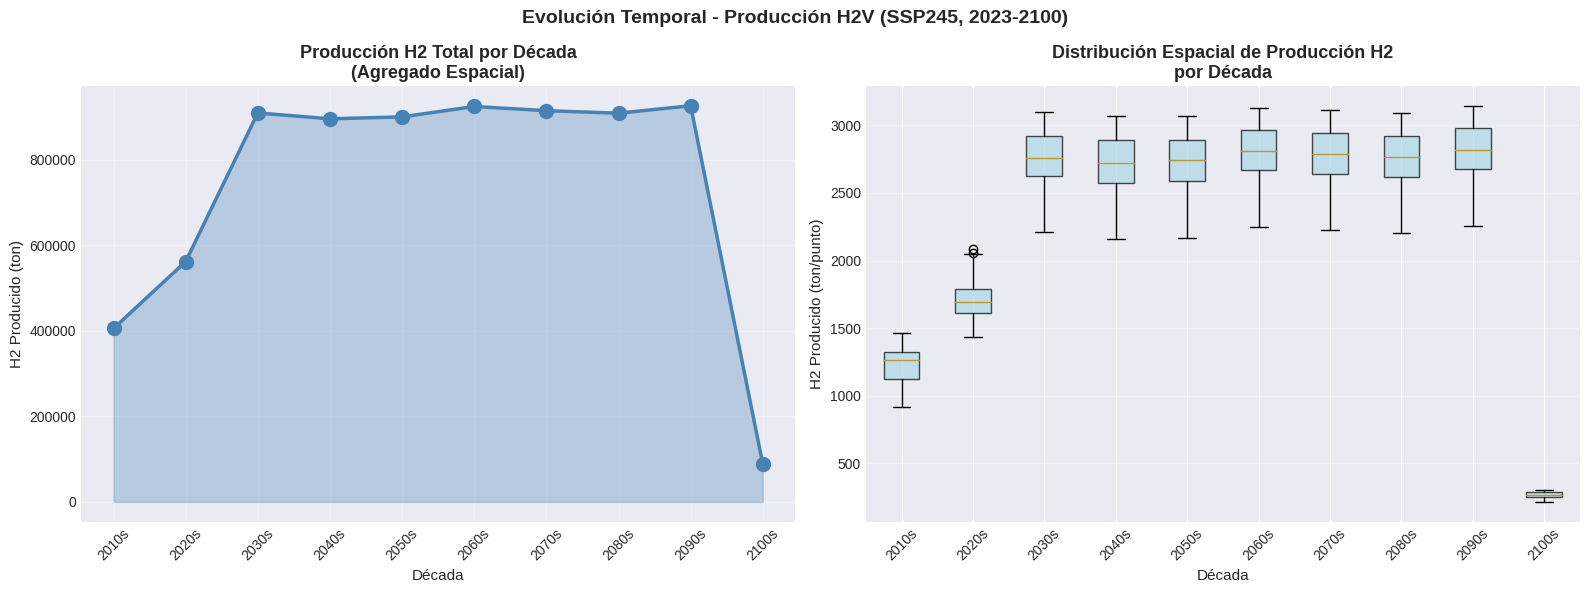


🌍 ESCENARIO: SSP370

✓ Décadas detectadas: 10
   Rango: h2_prod_2010s_ton a h2_prod_2100s_ton

📊 Producción Total por Década (suma de 330 puntos):
   2010s: 419,334.7 ton total | 1270.7 ton/punto promedio
   2020s: 584,584.6 ton total | 1771.5 ton/punto promedio
   2030s: 895,532.2 ton total | 2713.7 ton/punto promedio
   2040s: 913,579.4 ton total | 2768.4 ton/punto promedio
   2050s: 916,253.6 ton total | 2776.5 ton/punto promedio
   2060s: 916,402.6 ton total | 2777.0 ton/punto promedio
   2070s: 906,959.5 ton total | 2748.4 ton/punto promedio
   2080s: 899,489.4 ton total | 2725.7 ton/punto promedio
   2090s: 901,783.0 ton total | 2732.7 ton/punto promedio
   2100s: 89,353.0 ton total | 270.8 ton/punto promedio

📈 Tendencia temporal:
   Primera década: 419,334.7 ton
   Última década: 89,353.0 ton
   Cambio: -78.69%

✅ Gráfico guardado: /home/aninotna/magister/tesis/justh2_pipeline/data/h2v_production_spatial/distributed_point_by_point/ssp370/temporal_evolution_ssp370_full.png

✅ G

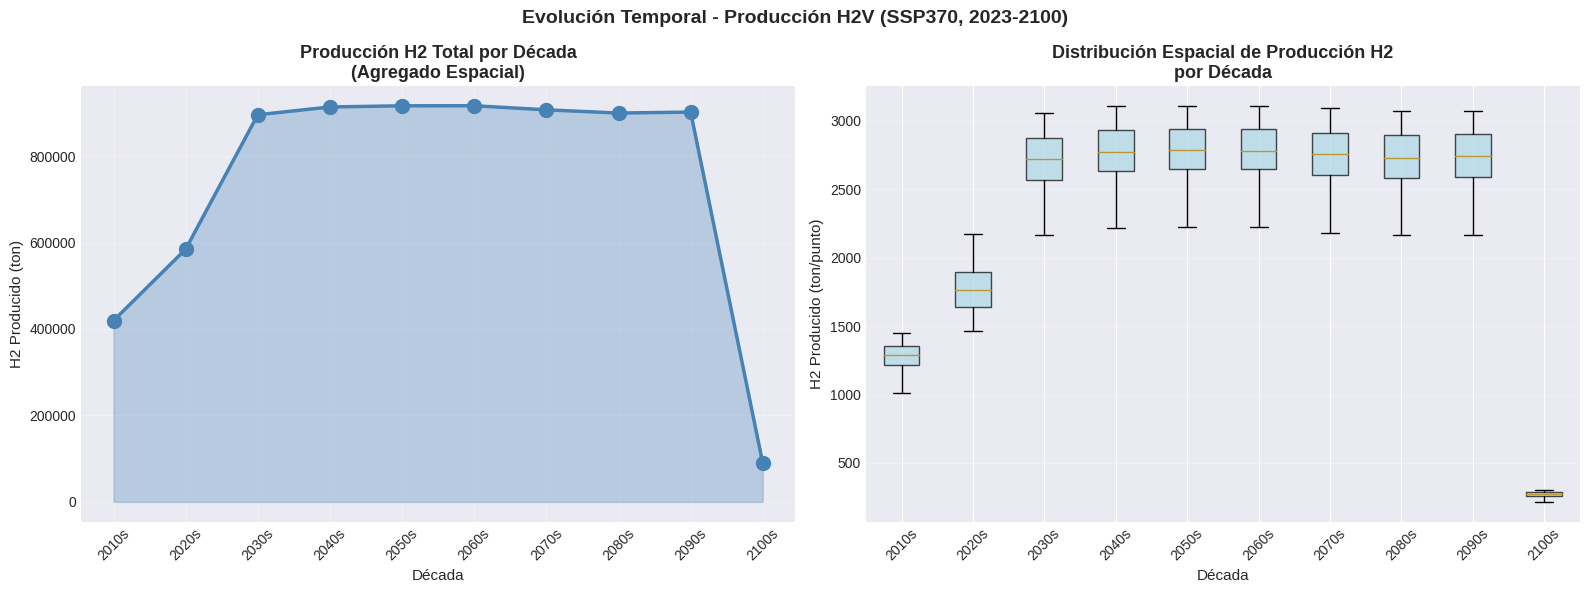


🌍 ESCENARIO: SSP585

✓ Décadas detectadas: 10
   Rango: h2_prod_2010s_ton a h2_prod_2100s_ton

📊 Producción Total por Década (suma de 330 puntos):
   2010s: 410,217.8 ton total | 1243.1 ton/punto promedio
   2020s: 559,234.5 ton total | 1694.6 ton/punto promedio
   2030s: 905,718.7 ton total | 2744.6 ton/punto promedio
   2040s: 929,773.4 ton total | 2817.5 ton/punto promedio
   2050s: 912,596.8 ton total | 2765.4 ton/punto promedio
   2060s: 906,387.3 ton total | 2746.6 ton/punto promedio
   2070s: 918,271.9 ton total | 2782.6 ton/punto promedio
   2080s: 926,777.6 ton total | 2808.4 ton/punto promedio
   2090s: 922,174.4 ton total | 2794.5 ton/punto promedio
   2100s: 92,359.3 ton total | 279.9 ton/punto promedio

📈 Tendencia temporal:
   Primera década: 410,217.8 ton
   Última década: 92,359.3 ton
   Cambio: -77.49%

✅ Gráfico guardado: /home/aninotna/magister/tesis/justh2_pipeline/data/h2v_production_spatial/distributed_point_by_point/ssp585/temporal_evolution_ssp585_full.png

✅ G

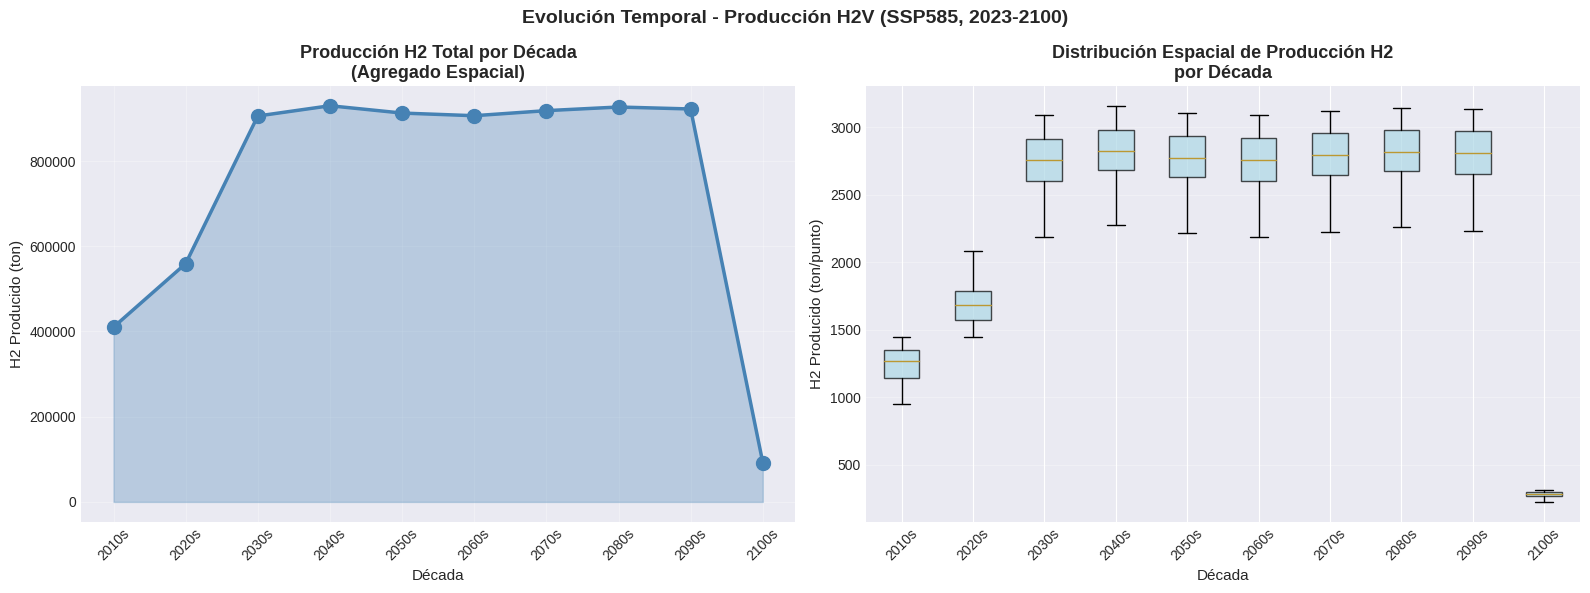

In [10]:
# ========== EVOLUCIÓN TEMPORAL POR ESCENARIO ==========
# Genera gráficos de evolución temporal para cada escenario del loop multi-escenario

print("\n" + "=" * 80)
print("📅 EVOLUCIÓN TEMPORAL DE PRODUCCIÓN H2 POR DÉCADA")
print("=" * 80)

# Verificar que tenemos resultados en memoria
if 'all_scenarios_results' not in globals() or len(all_scenarios_results) == 0:
    print("\n⚠️ No hay resultados del loop multi-escenario en memoria")
    print("   Ejecuta primero el loop multi-escenario (celda 15)")
else:
    print(f"\n✓ Escenarios disponibles: {list(all_scenarios_results.keys())}")
    
    # Procesar cada escenario
    for scenario, results_data in all_scenarios_results.items():
        df_success_scenario = results_data['df_success']
        
        if len(df_success_scenario) == 0:
            print(f"\n⚠️ {scenario.upper()}: Sin resultados exitosos")
            continue
        
        print(f"\n{'='*80}")
        print(f"🌍 ESCENARIO: {scenario.upper()}")
        print(f"{'='*80}")
        
        # Identificar columnas de décadas
        decade_cols = [col for col in df_success_scenario.columns if col.startswith('h2_prod_2') and col.endswith('s_ton')]
        
        if decade_cols:
            print(f"\n✓ Décadas detectadas: {len(decade_cols)}")
            print(f"   Rango: {min(decade_cols)} a {max(decade_cols)}")
            
            # Estadísticas por década (agregado espacial)
            print(f"\n📊 Producción Total por Década (suma de {len(df_success_scenario)} puntos):")
            
            for col in sorted(decade_cols):
                decade_label = col.replace('h2_prod_', '').replace('s_ton', 's')
                total = df_success_scenario[col].sum()
                mean = df_success_scenario[col].mean()
                print(f"   {decade_label}: {total:,.1f} ton total | {mean:.1f} ton/punto promedio")
            
            # Calcular tendencia temporal
            if len(decade_cols) > 1:
                first_decade = df_success_scenario[sorted(decade_cols)[0]].sum()
                last_decade = df_success_scenario[sorted(decade_cols)[-1]].sum()
                change_pct = ((last_decade - first_decade) / first_decade) * 100 if first_decade > 0 else 0
                
                print(f"\n📈 Tendencia temporal:")
                print(f"   Primera década: {first_decade:,.1f} ton")
                print(f"   Última década: {last_decade:,.1f} ton")
                print(f"   Cambio: {change_pct:+.2f}%")
            
            # Visualización: Evolución temporal
            fig, axes = plt.subplots(1, 2, figsize=(16, 6))
            
            # Gráfico 1: Serie temporal agregada
            ax1 = axes[0]
            decade_labels = [col.replace('h2_prod_', '').replace('s_ton', 's') for col in sorted(decade_cols)]
            decade_values = [df_success_scenario[col].sum() for col in sorted(decade_cols)]
            
            ax1.plot(decade_labels, decade_values, marker='o', linewidth=2.5, markersize=10, color='steelblue')
            ax1.fill_between(range(len(decade_labels)), decade_values, alpha=0.3, color='steelblue')
            ax1.set_title('Producción H2 Total por Década\n(Agregado Espacial)', fontsize=13, fontweight='bold')
            ax1.set_xlabel('Década', fontsize=11)
            ax1.set_ylabel('H2 Producido (ton)', fontsize=11)
            ax1.grid(True, alpha=0.3)
            ax1.tick_params(axis='x', rotation=45)
            
            # Gráfico 2: Distribución por década (boxplot)
            ax2 = axes[1]
            decade_data = [df_success_scenario[col].dropna() for col in sorted(decade_cols)]
            bp = ax2.boxplot(decade_data, labels=decade_labels, patch_artist=True)
            
            for patch in bp['boxes']:
                patch.set_facecolor('lightblue')
                patch.set_alpha(0.7)
            
            ax2.set_title('Distribución Espacial de Producción H2\npor Década', fontsize=13, fontweight='bold')
            ax2.set_xlabel('Década', fontsize=11)
            ax2.set_ylabel('H2 Producido (ton/punto)', fontsize=11)
            ax2.grid(True, alpha=0.3, axis='y')
            ax2.tick_params(axis='x', rotation=45)
            
            period_str = "2023-2043" if TEST_MODE else "2023-2100"
            plt.suptitle(f'Evolución Temporal - Producción H2V ({scenario.upper()}, {period_str})', 
                         fontsize=14, fontweight='bold')
            plt.tight_layout()
            
            # Guardar en subdirectorio del escenario
            scenario_output_dir = DATA_DIR / 'h2v_production_spatial' / 'distributed_point_by_point' / scenario
            mode_str = 'test' if TEST_MODE else 'full'
            temporal_plot_path = scenario_output_dir / f'temporal_evolution_{scenario}_{mode_str}.png'
            plt.savefig(temporal_plot_path, dpi=300, bbox_inches='tight')
            print(f"\n✅ Gráfico guardado: {temporal_plot_path}")
            
            plt.show()
            
        else:
            print(f"\n⚠️ No se encontraron columnas de producción por década")
            print(f"   Columnas disponibles: {df_success_scenario.columns.tolist()}")

print("\n" + "=" * 80)

## 8️⃣ Visualización Espacial - Mapas de Potencial H2

Generando mapas espaciales...
✅ Mapas guardados: spatial_maps_ssp585_full.png
✅ Mapas guardados: spatial_maps_ssp585_full.png


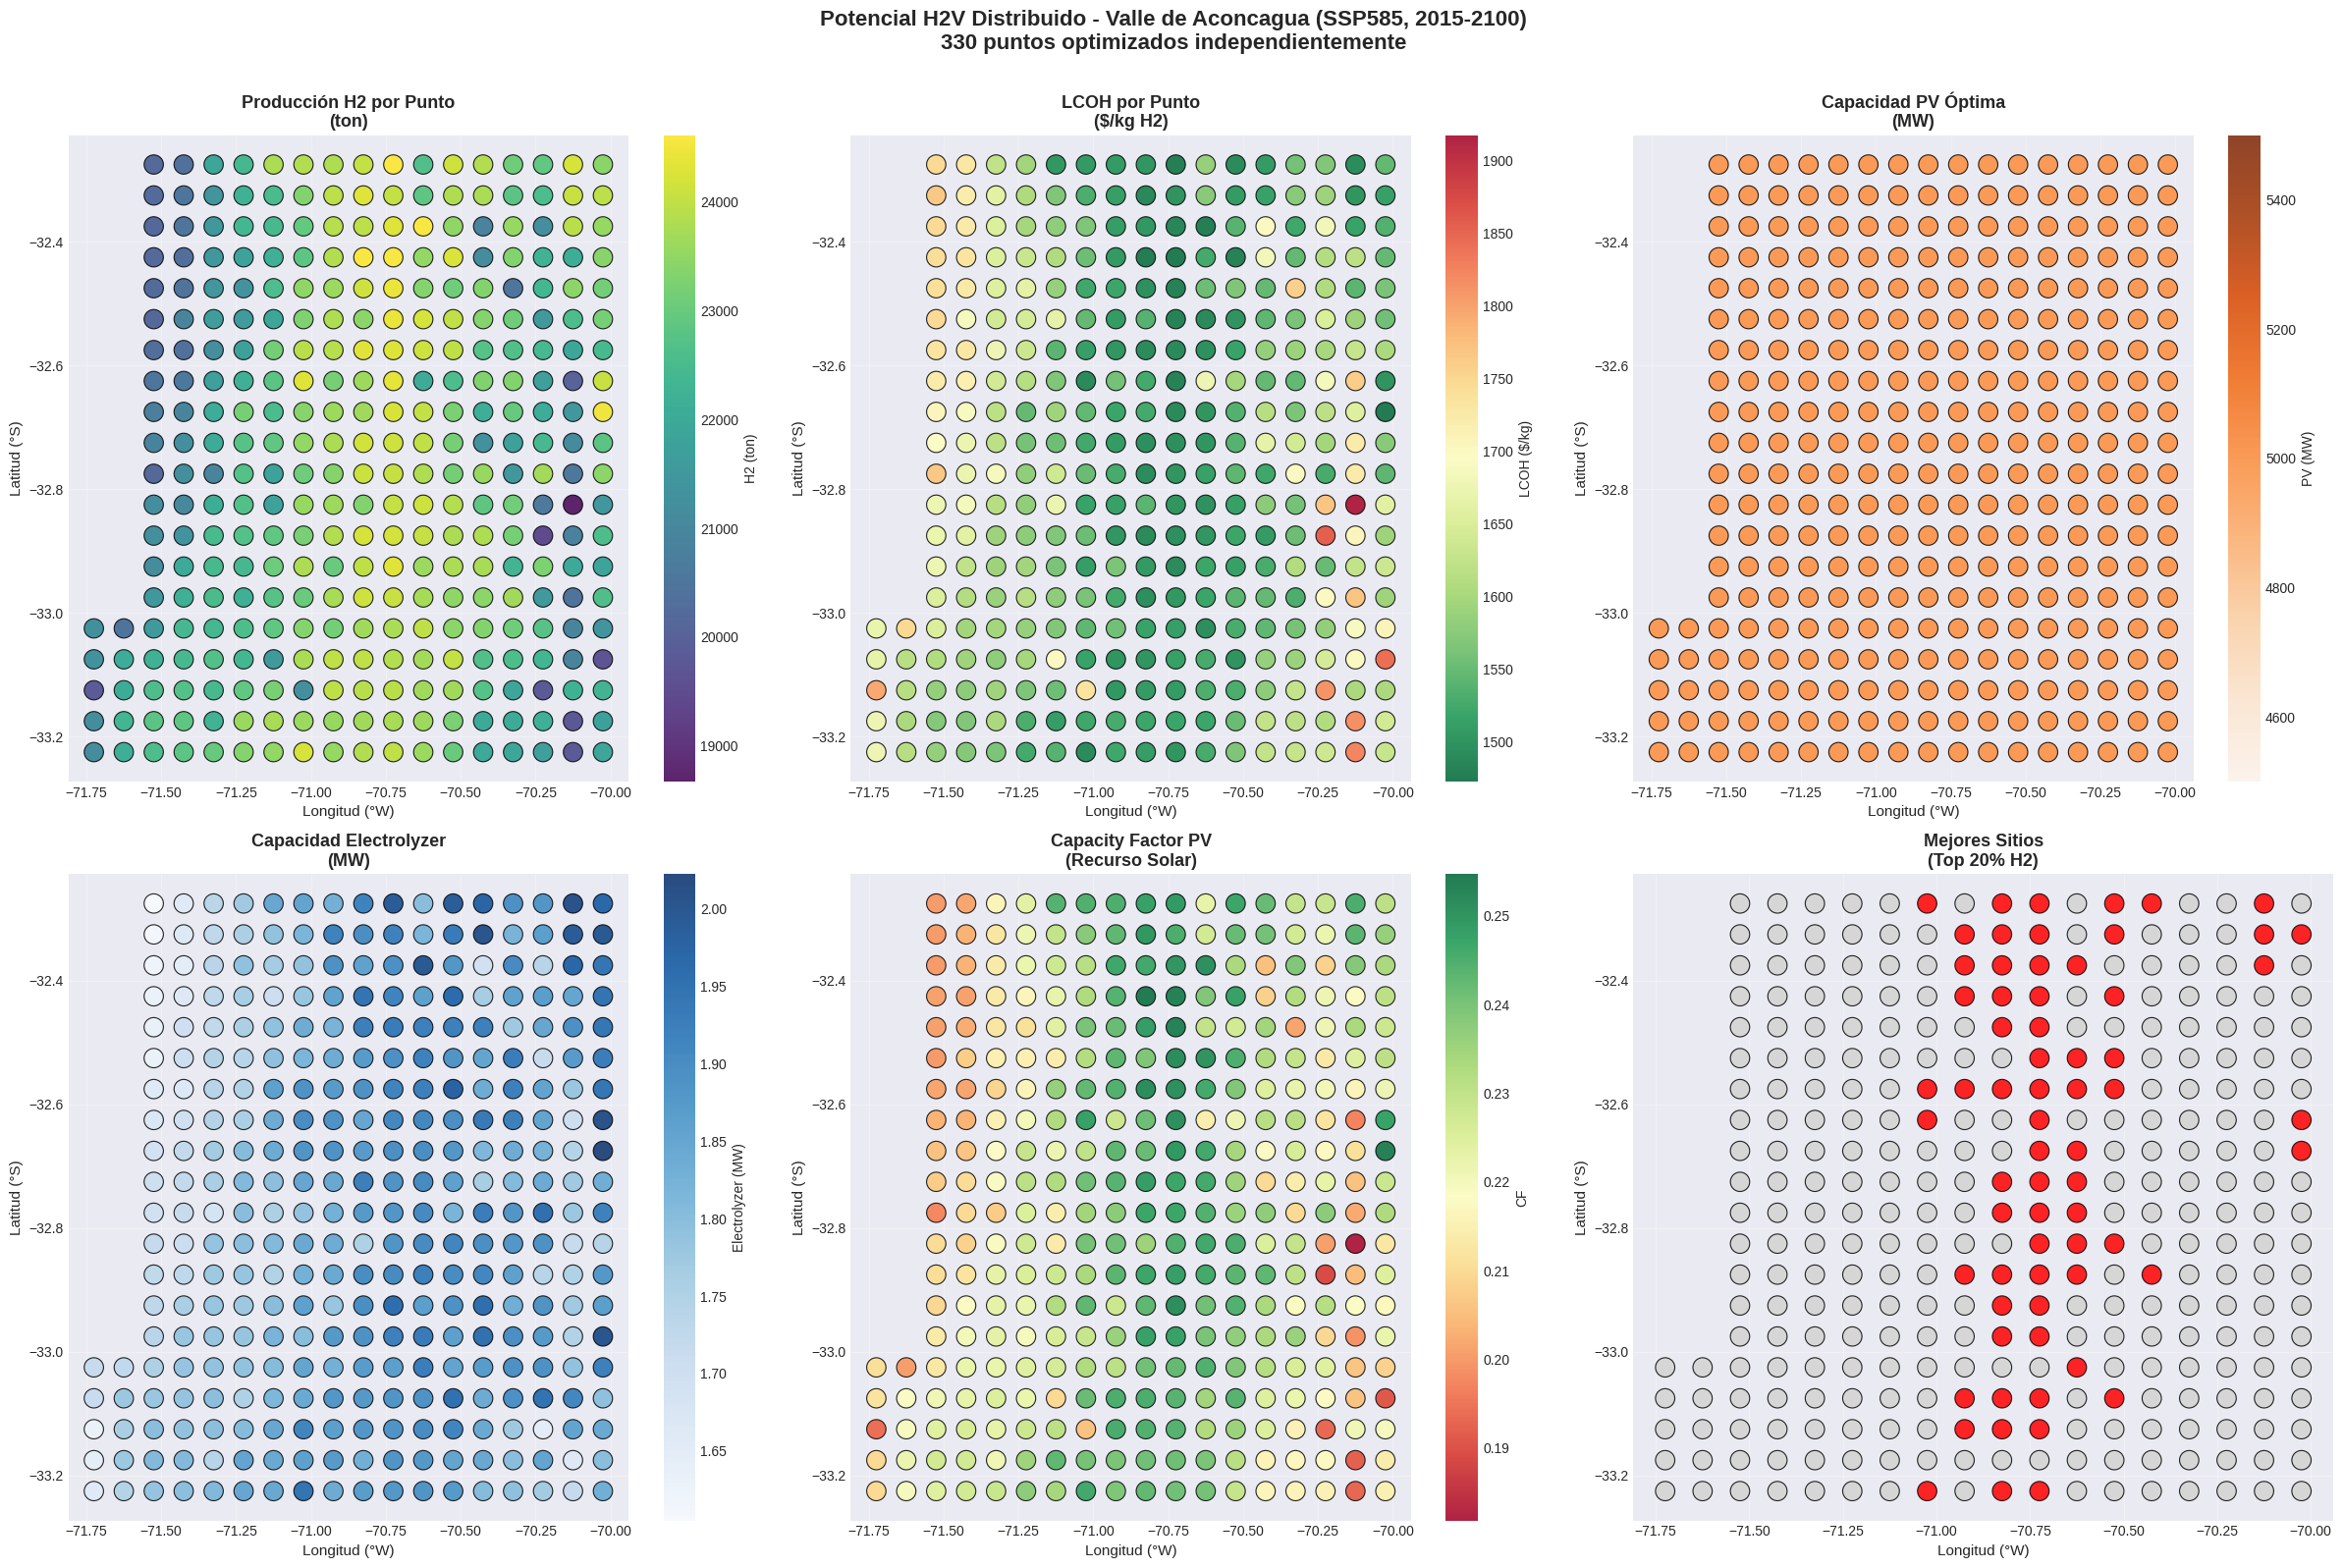

In [11]:
if len(df_success) == 0:
    print("⚠️ No hay resultados exitosos para visualizar")
else:
    print("Generando mapas espaciales...")
    
    fig, axes = plt.subplots(2, 3, figsize=(24, 16))
    
    # Mapa 1: Producción H2
    ax1 = axes[0, 0]
    scatter1 = ax1.scatter(df_success['lon'], df_success['lat'], 
                           c=df_success['h2_prod_ton'], s=200,
                           cmap='viridis', edgecolors='black', linewidth=0.8, alpha=0.85)
    ax1.set_title('Producción H2 por Punto\n(ton)', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Longitud (°W)', fontsize=11)
    ax1.set_ylabel('Latitud (°S)', fontsize=11)
    ax1.grid(True, alpha=0.3)
    cbar1 = plt.colorbar(scatter1, ax=ax1)
    cbar1.set_label('H2 (ton)', fontsize=10)
    
    # Mapa 2: LCOH
    ax2 = axes[0, 1]
    scatter2 = ax2.scatter(df_success['lon'], df_success['lat'], 
                           c=df_success['lcoh_usd_kg'], s=200,
                           cmap='RdYlGn_r', edgecolors='black', linewidth=0.8, alpha=0.85)
    ax2.set_title('LCOH por Punto\n($/kg H2)', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Longitud (°W)', fontsize=11)
    ax2.set_ylabel('Latitud (°S)', fontsize=11)
    ax2.grid(True, alpha=0.3)
    cbar2 = plt.colorbar(scatter2, ax=ax2)
    cbar2.set_label('LCOH ($/kg)', fontsize=10)
    
    # Mapa 3: Capacidad PV
    ax3 = axes[0, 2]
    scatter3 = ax3.scatter(df_success['lon'], df_success['lat'], 
                           c=df_success['cap_pv_mw'], s=200,
                           cmap='Oranges', edgecolors='black', linewidth=0.8, alpha=0.85)
    ax3.set_title('Capacidad PV Óptima\n(MW)', fontsize=13, fontweight='bold')
    ax3.set_xlabel('Longitud (°W)', fontsize=11)
    ax3.set_ylabel('Latitud (°S)', fontsize=11)
    ax3.grid(True, alpha=0.3)
    cbar3 = plt.colorbar(scatter3, ax=ax3)
    cbar3.set_label('PV (MW)', fontsize=10)
    
    # Mapa 4: Capacidad Electrolyzer
    ax4 = axes[1, 0]
    scatter4 = ax4.scatter(df_success['lon'], df_success['lat'], 
                           c=df_success['cap_electrolyzer_mw'], s=200,
                           cmap='Blues', edgecolors='black', linewidth=0.8, alpha=0.85)
    ax4.set_title('Capacidad Electrolyzer\n(MW)', fontsize=13, fontweight='bold')
    ax4.set_xlabel('Longitud (°W)', fontsize=11)
    ax4.set_ylabel('Latitud (°S)', fontsize=11)
    ax4.grid(True, alpha=0.3)
    cbar4 = plt.colorbar(scatter4, ax=ax4)
    cbar4.set_label('Electrolyzer (MW)', fontsize=10)
    
    # Mapa 5: CF Input
    ax5 = axes[1, 1]
    scatter5 = ax5.scatter(df_success['lon'], df_success['lat'], 
                           c=df_success['cf_mean'], s=200,
                           cmap='RdYlGn', edgecolors='black', linewidth=0.8, alpha=0.85)
    ax5.set_title('Capacity Factor PV\n(Recurso Solar)', fontsize=13, fontweight='bold')
    ax5.set_xlabel('Longitud (°W)', fontsize=11)
    ax5.set_ylabel('Latitud (°S)', fontsize=11)
    ax5.grid(True, alpha=0.3)
    cbar5 = plt.colorbar(scatter5, ax=ax5)
    cbar5.set_label('CF', fontsize=10)
    
    # Mapa 6: Ranking Top 20%
    ax6 = axes[1, 2]
    df_success['h2_percentile'] = df_success['h2_prod_ton'].rank(pct=True)
    top_20 = df_success['h2_percentile'] >= 0.8
    colors = ['red' if x else 'lightgray' for x in top_20]
    ax6.scatter(df_success['lon'], df_success['lat'], 
                c=colors, s=200,
                edgecolors='black', linewidth=0.8, alpha=0.85)
    ax6.set_title('Mejores Sitios\n(Top 20% H2)', fontsize=13, fontweight='bold')
    ax6.set_xlabel('Longitud (°W)', fontsize=11)
    ax6.set_ylabel('Latitud (°S)', fontsize=11)
    ax6.grid(True, alpha=0.3)
    
    # Título general
    period_str = "2023-2043" if TEST_MODE else "2015-2100"
    plt.suptitle(f'Potencial H2V Distribuido - Valle de Aconcagua ({SCENARIO.upper()}, {period_str})\n'
                 f'{len(df_success)} puntos optimizados independientemente',
                 fontsize=16, fontweight='bold', y=0.995)
    
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    
    # Guardar
    map_path = OUTPUT_DIR / f'spatial_maps_{SCENARIO}_{"test" if TEST_MODE else "full"}.png'
    plt.savefig(map_path, dpi=300, bbox_inches='tight')
    print(f"✅ Mapas guardados: {map_path.name}")
    
    plt.show()

## 9️⃣ Análisis de Sensibilidad - Identificar Zonas Óptimas

In [12]:
if len(df_success) > 0:
    print("=" * 80)
    print("🎯 ANÁLISIS DE ZONAS ÓPTIMAS")
    print("=" * 80)
    
    # Top 10%, 20%, 50% sitios por producción H2
    for pct in [10, 20, 50]:
        threshold = df_success['h2_prod_ton'].quantile(1 - pct/100)
        top_sites = df_success[df_success['h2_prod_ton'] >= threshold]
        
        print(f"\n📊 Top {pct}% Sitios por Producción H2:")
        print(f"   Umbral: {threshold:.1f} ton")
        print(f"   Número de sitios: {len(top_sites)}")
        print(f"   Producción total: {top_sites['h2_prod_ton'].sum():.1f} ton")
        print(f"   LCOH promedio: ${top_sites['lcoh_usd_kg'].mean():.2f}/kg")
        print(f"   CF promedio: {top_sites['cf_mean'].mean():.4f}")
        
        # Rango geográfico
        print(f"   Rango geográfico:")
        print(f"     Lat: {top_sites['lat'].min():.3f} a {top_sites['lat'].max():.3f}")
        print(f"     Lon: {top_sites['lon'].min():.3f} a {top_sites['lon'].max():.3f}")
    
    # Correlación CF vs H2 producido
    corr = df_success['cf_mean'].corr(df_success['h2_prod_ton'])
    print(f"\n📈 Correlación CF vs H2 producido: {corr:.3f}")
    
    print("=" * 80)

🎯 ANÁLISIS DE ZONAS ÓPTIMAS

📊 Top 10% Sitios por Producción H2:
   Umbral: 24042.1 ton
   Número de sitios: 33
   Producción total: 800663.1 ton
   LCOH promedio: $1489.05/kg
   CF promedio: 0.2489
   Rango geográfico:
     Lat: -33.225 a -32.275
     Lon: -71.025 a -70.025

📊 Top 20% Sitios por Producción H2:
   Umbral: 23819.3 ton
   Número de sitios: 66
   Producción total: 1590526.2 ton
   LCOH promedio: $1497.50/kg
   CF promedio: 0.2464
   Rango geográfico:
     Lat: -33.225 a -32.275
     Lon: -71.025 a -70.025

📊 Top 50% Sitios por Producción H2:
   Umbral: 22863.9 ton
   Número de sitios: 165
   Producción total: 3907389.0 ton
   LCOH promedio: $1521.92/kg
   CF promedio: 0.2397
   Rango geográfico:
     Lat: -33.225 a -32.275
     Lon: -71.325 a -70.025

📈 Correlación CF vs H2 producido: 0.985


## 📊 Análisis Comparativo Entre Escenarios

In [13]:
# ========== COMPARACIÓN ENTRE ESCENARIOS SSP ==========
# Esta celda analiza los resultados del loop multi-escenario (celda anterior)

print("\n" + "=" * 80)
print("📊 COMPARACIÓN ENTRE ESCENARIOS SSP")
print("=" * 80)

# Verificar que tenemos resultados en memoria
if 'all_scenarios_results' not in globals() or len(all_scenarios_results) == 0:
    print("\n⚠️ No hay resultados en memoria (variable all_scenarios_results)")
    print("   Ejecuta primero el loop multi-escenario (celda anterior)")
else:
    print(f"\n✓ Escenarios disponibles: {list(all_scenarios_results.keys())}")
    
    # Crear DataFrame comparativo
    comparison_stats = []
    
    for scenario in ['ssp245', 'ssp370', 'ssp585']:
        if scenario in all_scenarios_results:
            df_success = all_scenarios_results[scenario]['df_success']
            
            if len(df_success) > 0:
                stats = {
                    'Escenario': scenario.upper(),
                    'Puntos_exitosos': len(df_success),
                    'H2_total_ton': df_success['h2_prod_ton'].sum(),
                    'H2_promedio_ton': df_success['h2_prod_ton'].mean(),
                    'H2_max_ton': df_success['h2_prod_ton'].max(),
                    'H2_min_ton': df_success['h2_prod_ton'].min(),
                    'LCOH_promedio_usd_kg': df_success['lcoh_usd_kg'].mean(),
                    'LCOH_min_usd_kg': df_success['lcoh_usd_kg'].min(),
                    'LCOH_max_usd_kg': df_success['lcoh_usd_kg'].max(),
                    'Cap_PV_promedio_MW': df_success['cap_pv_mw'].mean(),
                    'Cap_Electrolyzer_promedio_MW': df_success['cap_electrolyzer_mw'].mean(),
                    'CF_promedio': df_success['cf_mean'].mean()
                }
                comparison_stats.append(stats)
    
    if len(comparison_stats) > 0:
        df_comparison = pd.DataFrame(comparison_stats)
        
        print("\n📈 Resumen por Escenario:")
        print(df_comparison.to_string(index=False))
        
        # Calcular diferencias relativas respecto a SSP245
        if len(df_comparison) >= 2 and 'SSP245' in df_comparison['Escenario'].values:
            print("\n📊 DIFERENCIAS RELATIVAS (respecto a SSP245):")
            print("=" * 80)
            
            baseline = df_comparison[df_comparison['Escenario'] == 'SSP245'].iloc[0]
            
            for _, row in df_comparison.iterrows():
                if row['Escenario'] != 'SSP245':
                    print(f"\n{row['Escenario']} vs SSP245:")
                    
                    h2_diff = ((row['H2_total_ton'] - baseline['H2_total_ton']) / baseline['H2_total_ton']) * 100
                    lcoh_diff = ((row['LCOH_promedio_usd_kg'] - baseline['LCOH_promedio_usd_kg']) / baseline['LCOH_promedio_usd_kg']) * 100
                    cf_diff = ((row['CF_promedio'] - baseline['CF_promedio']) / baseline['CF_promedio']) * 100
                    
                    print(f"  H2 Total: {h2_diff:+.2f}%")
                    print(f"  LCOH Promedio: {lcoh_diff:+.2f}%")
                    print(f"  CF Promedio: {cf_diff:+.2f}%")
        
        print("\n" + "=" * 80)
        
        # Guardar comparación
        mode_str = 'test' if TEST_MODE else 'full'
        
        # Guardar en directorio padre (un nivel arriba de los subdirectorios por escenario)
        comparison_dir = DATA_DIR / 'h2v_production_spatial' / 'distributed_point_by_point'
        comparison_csv = comparison_dir / f'comparison_scenarios_{mode_str}.csv'
        df_comparison.to_csv(comparison_csv, index=False)
        print(f"\n💾 Comparación guardada: {comparison_csv}")
        
        print(f"\n✅ Archivos CSV individuales por escenario ya guardados:")
        for scenario in all_scenarios_results.keys():
            scenario_dir = comparison_dir / scenario
            csv_file = scenario_dir / f'h2_distributed_{scenario}_{mode_str}.csv'
            if csv_file.exists():
                print(f"   ✓ {csv_file}")
    else:
        print("\n⚠️ No se generaron estadísticas de comparación")
        print("   Verifica que los DataFrames tengan datos exitosos")

print("=" * 80)


📊 COMPARACIÓN ENTRE ESCENARIOS SSP

✓ Escenarios disponibles: ['ssp245', 'ssp370', 'ssp585']

📈 Resumen por Escenario:
Escenario  Puntos_exitosos  H2_total_ton  H2_promedio_ton   H2_max_ton   H2_min_ton  LCOH_promedio_usd_kg  LCOH_min_usd_kg  LCOH_max_usd_kg  Cap_PV_promedio_MW  Cap_Electrolyzer_promedio_MW  CF_promedio
   SSP245              330  7.439509e+06     22543.967359 24676.524148 18535.362833           1592.168377      1465.678435      1929.576995              5000.0                      1.823273     0.224917
   SSP370              330  7.443272e+06     22555.369919 24686.146211 18432.460194           1602.147635      1473.112280      1940.934300              5000.0                      1.811601     0.224337
   SSP585              330  7.483512e+06     22677.308610 24614.823462 18671.720523           1586.618145      1472.527739      1917.579815              5000.0                      1.830430     0.227035

📊 DIFERENCIAS RELATIVAS (respecto a SSP245):

SSP370 vs SSP245:
  H